#**Evaluacion 2 | Aplicando Modelos Estadísticos**
  **Autores:** Nicolas Lizama, Agustin Jara , Leandro Caceres

---


##**Requisitos de Software**
Este notebook fue desarrollado con Python 3
A continuación se listan las bibliotecas necesarias:

* *pandas*
* *numpy*
* *matplotlib*
* *seaborn*
* *sklearn*






#**Fase 1 | Compresion de negocio**

##**Caso de negocio**

El sector hotelero enfrenta pérdidas económicas significativas debido a las cancelaciones de reservas, lo que complica la planificación operativa y genera costos asociados a habitaciones vacías que podrían haberse vendido.

El objetivo de Negocio Predecir las cancelaciones de reservas para optimizar la gestión hotelera, permitiendo la implementación de políticas de *overbooking* controlado, estrategias de precios dinámicos y políticas de depósito más efectivas.

Se utiliza un conjunto de datos real de **reservas de dos hoteles** (uno de ciudad y uno de resort) en **Portugal**, un país con alta dependencia del turismo. Los datos abarcan desde **julio de 2015** hasta **agosto de 2017** y contienen información sobre las características de la reserva, el perfil del cliente y el resultado final (cancelación o no).

**Factores Clave:** La capacidad de predecir las cancelaciones se basa en comprender la influencia de múltiples factores, como el tiempo de anticipación de la reserva (`lead_time`), el tipo de cliente, el canal de distribución, las políticas de depósito, el segmento de mercado y la estacionalidad. La variable objetivo principal es `is_canceled` (1 para cancelada, 0 para no cancelada), y `adr` (tarifa diaria promedio) es una medida económica relevante.



---

##**Variable Objetivo**

La variable Objetivo es **is_canceled**
(1 si la reserva fue cancelada, 0 si no)


##4 preguntas  (2 KPIS y 2 Insights)

### **KPI 1: Tasa de Cancelación según el Tipo de Hotel**

**Cualitativa:** `hotel`
**Cuantitativa:** `is_canceled` (como proporción)

$$
\text{Tasa de Cancelación}_{hotel} =
\frac{\text{Número de Reservas Canceladas del Tipo de Hotel}}
{\text{Número Total de Reservas del Tipo de Hotel}}
\times 100
$$

**Objetivo:** Comparar las tasas de cancelación entre `City Hotel` y `Resort Hotel` para identificar qué tipo de hotel es más propenso a las cancelaciones.

### **KPI 2: Influencia del Tipo de Depósito en la Tasa de Cancelación**

**Cualitativa:** `deposit_type`
**Cuantitativa:** `is_canceled` (como proporción)

$$
\text{Tasa de Cancelación por Tipo de Depósito} =
\frac{\text{Número de Reservas Canceladas según Tipo de Depósito}}
{\text{Número Total de Reservas según Tipo de Depósito}}
\times 100
$$

**Objetivo:** Analizar si ciertos tipos de depósito están asociados con tasas de cancelación más altas o más bajas.

### **Insight 1: Relación entre Solicitudes Especiales y Tasa de Cancelación**

**Cualitativa:** `total_of_special_requests`
**Cuantitativa:** `is_canceled` (como proporción)

**Objetivo:** Determinar si los clientes con solicitudes especiales son más o menos propensos a cancelar sus reservas.

### **Insight 2: Tasa de Cancelación según el Tipo de Cliente**

**Cualitativa:** `customer_type`
**Cuantitativa:** `is_canceled` (como proporción)

**Objetivo:** Comprender si ciertos tipos de clientes tienen una mayor propensión a cancelar, para apoyar estrategias de retención.

##Cargar librerias a utilizar

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay , classification_report

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold

import warnings
warnings.filterwarnings('ignore')

##Descargar Base de datos

In [2]:
url = "https://raw.githubusercontent.com/NicolasLizama/Titanicsehundio/main/hotels.csv"

##Cargar base de datos

In [3]:
#Leemos el csv como "data" usando pandas
data = pd.read_csv(url)
data.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


El dataset inicial contiene 119,390 filas y 32 columnas, lo que representa un amplio conjunto de información sobre reservas de hoteles.

##Diccionario de Variables


Los datos de `hotels.csv` están relacionados con la información de reservas de hoteles y pueden ser analizados para buscar patrones asociados a cancelaciones, comportamiento de reserva y factores que influyen en el precio. Las columnas principales son:

1.  **hotel**: Indica el tipo de hotel (Resort Hotel o City Hotel).
2.  **is_canceled**: Variable objetivo que indica si la reserva fue cancelada (1) o no (0).
3.  **lead_time**: Número de días entre la fecha de reserva y la fecha de llegada.
4.  **arrival_date_year**: Año de la fecha de llegada.
5.  **arrival_date_month**: Mes de la fecha de llegada.
6.  **arrival_date_week_number**: Número de semana del año de la fecha de llegada.
7.  **arrival_date_day_of_month**: Día del mes de la fecha de llegada.
8.  **stays_in_weekend_nights**: Número de noches de fin de semana (sábado o domingo) que el huésped reservó.
9.  **stays_in_week_nights**: Número de noches de entre semana (lunes a viernes) que el huésped reservó.
10. **adults**: Número de adultos en la reserva.
11. **children**: Número de niños en la reserva.
12. **babies**: Número de bebés en la reserva.
13. **meal**: Tipo de régimen de comidas reservado.
14. **country**: País de origen del cliente.
15. **market_segment**: Designación del segmento de mercado. En qué segmento de mercado se originó la reserva.
16. **distribution_channel**: Canal de distribución utilizado para hacer la reserva.
17. **is_repeated_guest**: Indica si el cliente es un huésped repetitivo (1) o no (0).
18. **previous_cancellations**: Número de cancelaciones previas del cliente.
19. **previous_bookings_not_canceled**: Número de reservas previas no canceladas del cliente.
20. **reserved_room_type**: Tipo de habitación reservada.
21. **assigned_room_type**: Tipo de habitación asignada. Puede ser diferente de la reservada debido a actualizaciones o disponibilidad.
22. **booking_changes**: Número de cambios realizados en la reserva desde el momento de la entrada hasta el momento de la verificación (check-in) o cancelación.
23. **deposit_type**: Indica si el cliente realizó un depósito para garantizar la reserva.
24. **agent**: ID del agente de viajes que realizó la reserva.
25. **company**: ID de la empresa/organización que realizó la reserva.
26. **days_in_waiting_list**: Número de días que la reserva estuvo en lista de espera.
27. **customer_type**: Tipo de cliente (por ejemplo, 'Transient', 'Contract', 'Group').
28. **adr**: Average Daily Rate (Tarifa Diaria Promedio): precio medio por día de la reserva.
29. **required_car_parking_spaces**: Número de plazas de aparcamiento requeridas por el cliente.
30. **total_of_special_requests**: Número total de peticiones especiales realizadas por el cliente.
31. **reservation_status**: Estado final de la reserva (Check-Out, Canceled, No-Show).
32. **reservation_status_date**: Fecha en que se estableció el último estado de la reserva.

#**Fase 2 | Compresion de los datos**

In [ ]:
data

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [ ]:
print(f"Cantidad de filas: {data.shape[0]}")
print(f"Cantidad de Columnas: {data.shape[1]}")

Cantidad de filas: 119390
Cantidad de Columnas: 32


El dataframe presenta un total de 119.390 filas y 32 columnas

##**Nombre y tipo de datos**

In [ ]:
print(data.dtypes)

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

##**Cantidad valores nulos**

In [ ]:
print("Valores nulos por columna:")
print(data.isnull().sum())

Valores nulos por columna:
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                         

* **Company** y **agent** deberian **descartarse debido a su alta cantidad de valores Nulos**, que podrian afectar al modelo.

* En cuanto a **country**, podria imputarse por la moda

* y **children** por la media


##Ver valores unicos

In [ ]:
tabla_unicos = pd.DataFrame({
    "Columna": data.columns,
    "Cantidad_Valores_Unicos": [data[col].nunique() for col in data.columns],
    "Valores_Unicos": [list(data[col].unique()) for col in data.columns]
})

tabla_unicos

,Columna,Cantidad_Valores_Unicos,Valores_Unicos
0,hotel,2,"[Resort Hotel, City Hotel]"
1,is_canceled,2,"[0, 1]"
2,lead_time,479,"[342, 737, 7, 13, 14, 0, 9, 85, 75, 23, 35, 68..."
3,arrival_date_year,3,"[2015, 2016, 2017]"
4,arrival_date_month,12,"[July, August, September, October, November, D..."
5,arrival_date_week_number,53,"[27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 3..."
6,arrival_date_day_of_month,31,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
7,stays_in_weekend_nights,17,"[0, 1, 2, 4, 3, 6, 13, 8, 5, 7, 12, 9, 16, 18,..."
8,stays_in_week_nights,35,"[0, 1, 2, 3, 4, 5, 10, 11, 8, 6, 7, 15, 9, 12,..."
9,adults,14,"[2, 1, 3, 4, 40, 26, 50, 27, 55, 0, 20, 6, 5, 10]"


A primera vista, se deberian transformar **children**, **agent** y **company** a int, ya que estas variables no hacen uso de numero decimales, solo un numero entero,

(ni modo que alguen tenga 2.5 hijos xd)

**adr** se deja igual ya que si hace uso del decimal.

##**Detección de valores negativos**

In [ ]:
(data.select_dtypes(include='number') < 0).any().rename("¿Existen valores negativos?")

is_canceled                       False
lead_time                         False
arrival_date_year                 False
arrival_date_week_number          False
arrival_date_day_of_month         False
stays_in_weekend_nights           False
stays_in_week_nights              False
adults                            False
children                          False
babies                            False
is_repeated_guest                 False
previous_cancellations            False
previous_bookings_not_canceled    False
booking_changes                   False
agent                             False
company                           False
days_in_waiting_list              False
adr                                True
required_car_parking_spaces       False
total_of_special_requests         False
Name: ¿Existen valores negativos?, dtype: bool

##**Detección de valores cero**

In [ ]:
(data == 0).sum().rename("Cantidad valores que son iguales a 0")

hotel                                  0
is_canceled                        75166
lead_time                           6345
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights            51998
stays_in_week_nights                7645
adults                               403
children                          110796
babies                            118473
meal                                   0
country                                0
market_segment                         0
distribution_channel                   0
is_repeated_guest                 115580
previous_cancellations            112906
previous_bookings_not_canceled    115770
reserved_room_type                     0
assigned_room_type                     0
booking_changes                   101314
deposit_type                           0
agent                                  0
company         

##**Calculos de medidas estadisticas**

In [ ]:
data.describe().round(2)

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119386.0,119390.00,119390.00,119390.00,119390.00,119390.00,103050.00,6797.00,119390.00,119390.00,119390.00,119390.00
mean,0.37,104.01,2016.16,27.17,15.80,0.93,2.50,1.86,0.1,0.01,0.03,0.09,0.14,0.22,86.69,189.27,2.32,101.83,0.06,0.57
std,0.48,106.86,0.71,13.61,8.78,1.00,1.91,0.58,0.4,0.10,0.18,0.84,1.50,0.65,110.77,131.66,17.59,50.54,0.25,0.79
min,0.00,0.00,2015.00,1.00,1.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,1.00,6.00,0.00,-6.38,0.00,0.00
25%,0.00,18.00,2016.00,16.00,8.00,0.00,1.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,9.00,62.00,0.00,69.29,0.00,0.00
50%,0.00,69.00,2016.00,28.00,16.00,1.00,2.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,14.00,179.00,0.00,94.58,0.00,0.00
75%,1.00,160.00,2017.00,38.00,23.00,2.00,3.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,229.00,270.00,0.00,126.00,0.00,1.00
max,1.00,737.00,2017.00,53.00,31.00,19.00,50.00,55.00,10.0,10.00,1.00,26.00,72.00,21.00,535.00,543.00,391.00,5400.00,8.00,5.00


##Revisar inconsistencias

In [ ]:
columnas_categoricas = [
    'hotel',
    'deposit_type',
    'market_segment',
    'customer_type',
    'arrival_date_month'
]
for col in columnas_categoricas:
    print(f'\n===== {col.upper()} =====')
    print(data[col].value_counts(dropna=False).to_string())


===== HOTEL =====
hotel
City Hotel      79330
Resort Hotel    40060

===== DEPOSIT_TYPE =====
deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162

===== MARKET_SEGMENT =====
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2

===== CUSTOMER_TYPE =====
customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577

===== ARRIVAL_DATE_MONTH =====
arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929


No se presencian inconcistencias en la base de datos

##Existencia de valores duplicados

In [ ]:
data.duplicated().sum()

np.int64(31994)

Existen 31.994 valores duplicados en total

##Distribución de la variable objetivo: **is_canceled**

is_canceled
0    75166
1    44224
Name: count, dtype: int64

is_canceled
0    63.0 %
1    37.0 %
Name: count, dtype: str


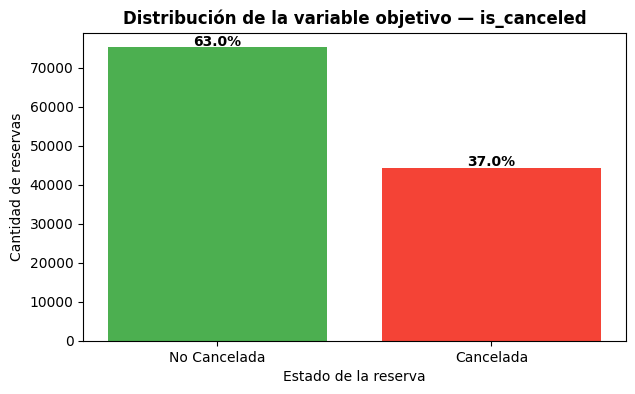

In [ ]:
conteo = data['is_canceled'].value_counts()

print(conteo)
print()
print((conteo / len(data) * 100).round(1).astype(str) + ' %')

# Etiquetas personalizadas
orden = [0, 1]
labels = ['No Cancelada', 'Cancelada']

# Colores personalizados
colores = ['#4CAF50', '#F44336']  # Verde y rojo

plt.figure(figsize=(7,4))

# Crear barras
bars = plt.bar(
    labels,
    [conteo.get(c, 0) for c in orden],
    color=colores
)

# Agregar porcentajes sobre las barras
for bar, val in zip(bars, [conteo.get(c, 0) for c in orden]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 500,
        f'{val/len(data)*100:.1f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Títulos y etiquetas
plt.title(
    'Distribución de la variable objetivo — is_canceled',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel('Cantidad de reservas')
plt.xlabel('Estado de la reserva')

plt.show()

En general los cliente suelen no cancelar su estadia en el hotel con 63% lo que cual es bueno no brillante, un 37% de gente suele si cancelar su estadia por diferentes razones que iremos descubriendo a lo largo de este notebook

##Distribucion de variables numericas

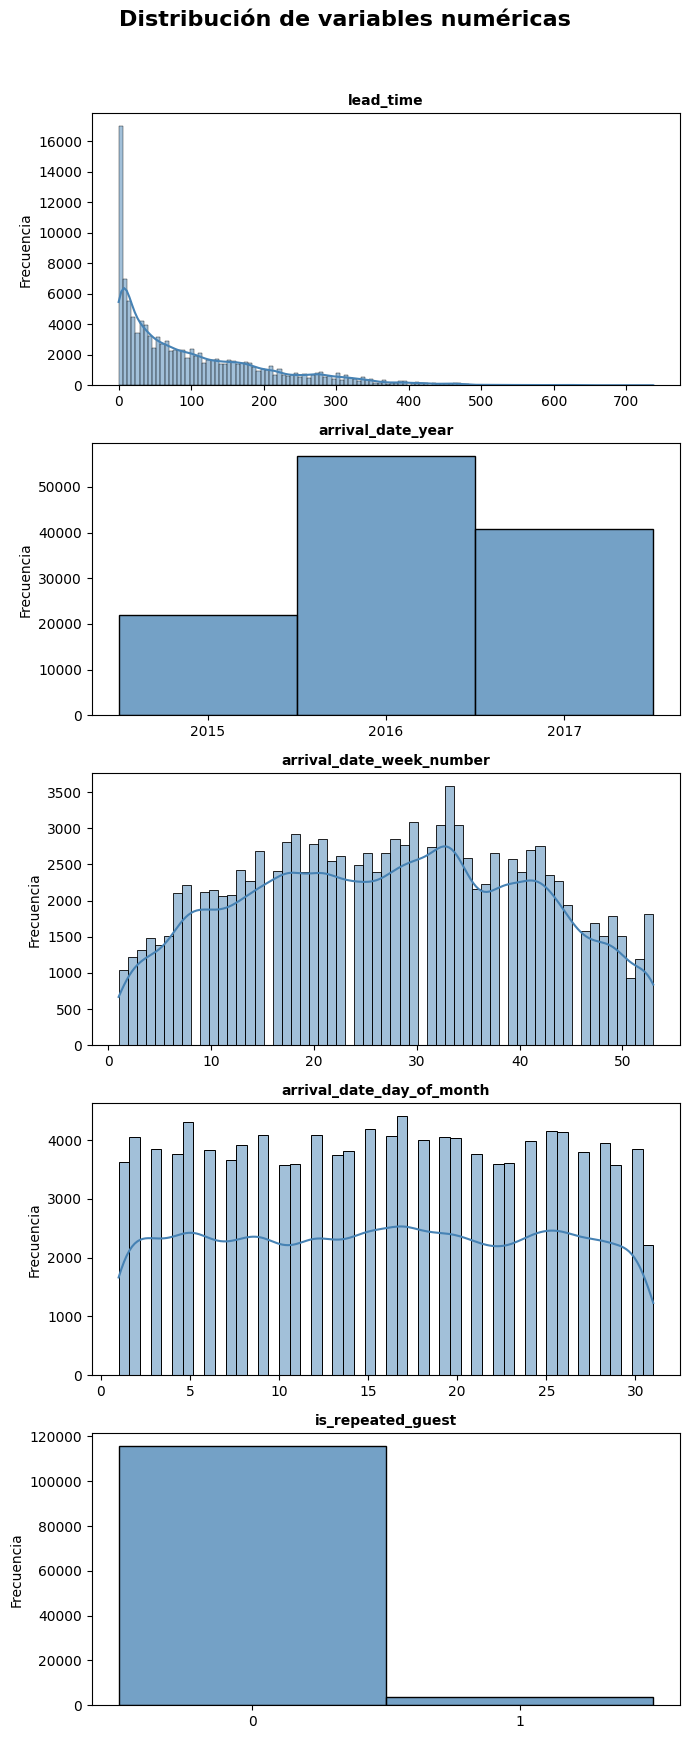

In [ ]:
# Lista de columnas a graficar
variables_numericas = [
    'lead_time',
    'arrival_date_year',
    'arrival_date_week_number',
    'arrival_date_day_of_month',
    'is_repeated_guest'
]

# Crear figura
fig, axes = plt.subplots(5, 1, figsize=(7, 17))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):

    # Variables discretas
    if col in ['arrival_date_year', 'is_repeated_guest']:

        sns.histplot(
            data=data,
            x=col,
            discrete=True,
            color='steelblue',
            ax=axes[i]
        )

        if col == 'arrival_date_year':
            axes[i].set_xticks([2015, 2016, 2017])

        elif col == 'is_repeated_guest':
            axes[i].set_xticks([0, 1])

    # Variables continuas
    else:
        sns.histplot(
            data=data,
            x=col,
            kde=True,
            color='steelblue',
            ax=axes[i]
        )

    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

# Título general
fig.suptitle(
    'Distribución de variables numéricas',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

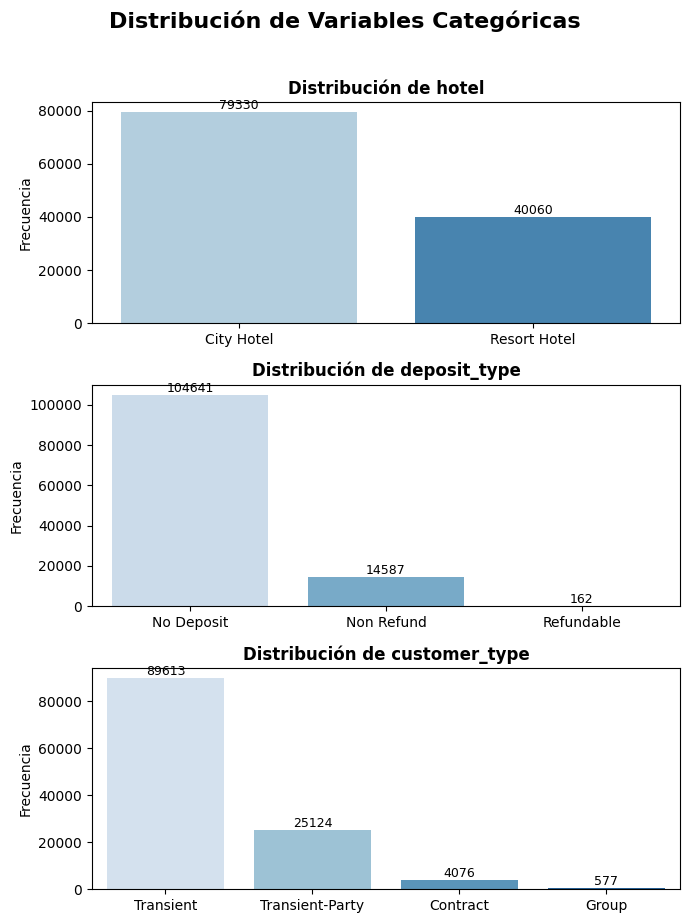

In [ ]:
variables_categoricas = [
    'hotel',
    'deposit_type',
    'customer_type'
]

fig, axes = plt.subplots(3, 1, figsize=(7, 9))
for i, col in enumerate(variables_categoricas):
    orden = data[col].value_counts().index

    sns.countplot(
        data=data,
        x=col,
        order=orden,
        palette='Blues',
        ax=axes[i]
    )

    axes[i].set_title(
        f'Distribución de {col}',
        fontsize=12,
        fontweight='bold'
    )

    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

    # Mostrar cantidad sobre cada barra
    for p in axes[i].patches:
        axes[i].annotate(
            f'{int(p.get_height())}',
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.suptitle(
    'Distribución de Variables Categóricas',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

##**Matriz de correlacion sin transformar categoricas**

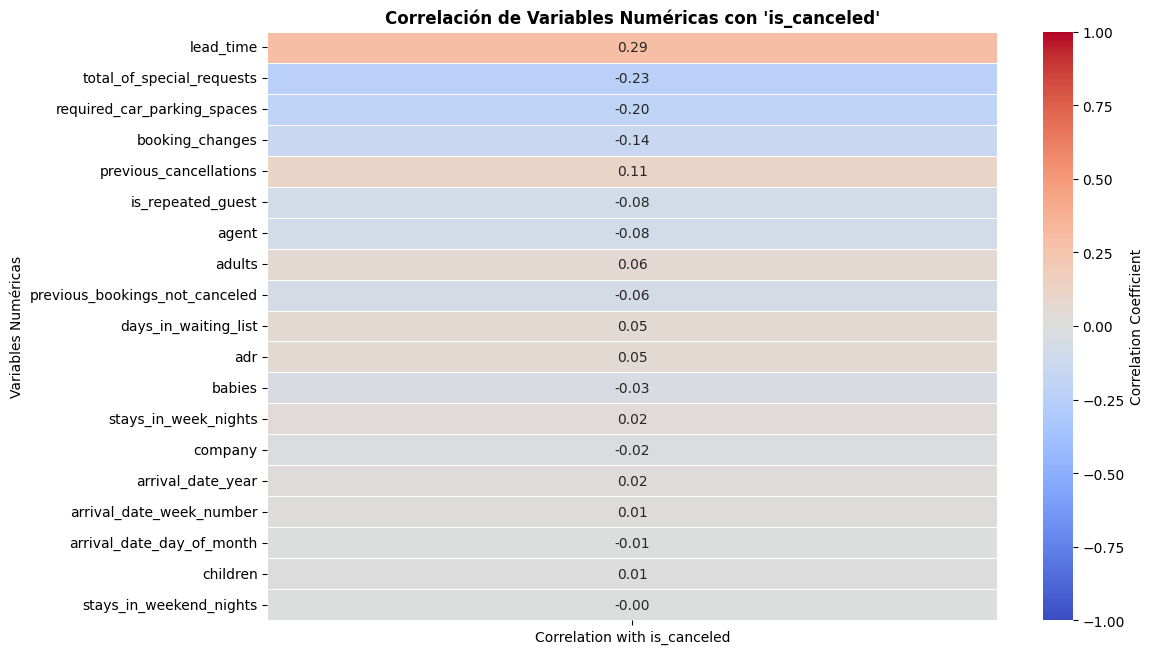

In [ ]:
# Seleccionamos solo las columnas numéricas
data_numerica = data.select_dtypes(include=['int64', 'float64'])

correlaciones_is_canceled = (
    data_numerica
    .corrwith(data_numerica['is_canceled'])
    .drop('is_canceled')
)

correlaciones_df = pd.DataFrame(
    correlaciones_is_canceled,
    columns=['Correlation with is_canceled']
)

correlaciones_df = correlaciones_df.dropna()

correlaciones_df = correlaciones_df.reindex(
    correlaciones_df['Correlation with is_canceled']
    .abs()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, len(correlaciones_df) * 0.35))

sns.heatmap(
    correlaciones_df,annot=True,fmt='.2f',cmap='coolwarm',vmin=-1,vmax=1,linewidths=.5,cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title(
    "Correlación de Variables Numéricas con 'is_canceled'",
    fontweight='bold'
)

plt.ylabel('Variables Numéricas')

plt.tight_layout()

plt.show()

Analizando la matriz de correlación con `is_canceled`, las relaciones más destacadas son:

*   **`lead_time` y `is_canceled`**: Una correlación positiva de **0.29**. Esto indica que cuanto mayor es el tiempo de anticipación de la reserva (`lead_time`), mayor es la probabilidad de que la reserva sea cancelada (`is_canceled`). Reservar con mucha antelación a menudo da a los clientes más flexibilidad para cambiar o cancelar sus planes.

*   **`total_of_special_requests` y `is_canceled`**: Una correlación negativa de **-0.23**. Esto sugiere que los clientes que realizan más solicitudes especiales son *menos* propensos a cancelar sus reservas. Esto podría indicar un mayor compromiso o una experiencia más personalizada que reduce la probabilidad de cancelación.

*   **`required_car_parking_spaces` y `is_canceled`**: Una correlación negativa de **-0.19**. Los clientes que requieren plazas de aparcamiento tienen una menor probabilidad de cancelar su reserva, lo que podría implicar un viaje más planificado y una mayor intención de cumplir la reserva.

*   **`booking_changes` y `is_canceled`**: Una correlación negativa de **-0.14**. Sorprendentemente, un mayor número de cambios en la reserva está asociado con una *menor* tasa de cancelación. Esto podría indicar que los clientes que ajustan su reserva en lugar de cancelarla están más comprometidos con la estancia.

*   **`previous_cancellations` y `is_canceled`**: Una correlación positiva de **0.11**. Como era de esperar, los clientes con un historial de cancelaciones previas son ligeramente más propensos a cancelar sus reservas futuras.

##**Visualizacion de valores atipicos**

Recordemos que para ver los atipicos se usa la técnica basada en los cuartiles, conocida como rango intercuartílico (IQR).


Se calculan tres valores clave:

1. **Q1 (cuartil 25%): valor por debajo del cual se encuentra el 25% de los datos**

2. **Q3 (cuartil 75%): valor por debajo del cual se encuentra el 75% de los datos**

IQR (rango intercuartílico): $$ IQR = Q3 - Q1 $$

Un dato se considera atípico si:

- Es menor al límite inferior:
$$
\text{Valor} < Q1 - 1.5 \cdot IQR
$$

- O superior al límite superior:
$$
\text{Valor} > Q3 + 1.5 \cdot IQR
$$

In [ ]:
def contar_outliers_iqr(data: pd.DataFrame):
    """
    Cuenta outliers usando IQR para TODAS las variables numéricas
    """
    resultados = []

    columnas = data.select_dtypes(include='number').columns

    for col in columnas:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        n_outliers = ((data[col] < limite_inferior) |
                      (data[col] > limite_superior)).sum()

        resultados.append({
            "columna": col,
            "outliers": int(n_outliers),
            "porcentaje_outliers": round(100 * n_outliers / len(data), 2),
            "limite_inferior": round(limite_inferior, 2),
            "limite_superior": round(limite_superior, 2)
        })

    return (
        pd.DataFrame(resultados)
        .sort_values(by="outliers", ascending=False)
        .reset_index(drop=True)
    )

outliers_iqr = contar_outliers_iqr(data)
outliers_iqr

,columna,outliers,porcentaje_outliers,limite_inferior,limite_superior
0,adults,29710,24.88,2.00,2.00
1,booking_changes,18076,15.14,0.00,0.00
2,children,8590,7.19,0.00,0.00
3,required_car_parking_spaces,7416,6.21,0.00,0.00
4,previous_cancellations,6484,5.43,0.00,0.00
5,is_repeated_guest,3810,3.19,0.00,0.00
6,adr,3793,3.18,-15.77,211.06
7,days_in_waiting_list,3698,3.10,0.00,0.00
8,previous_bookings_not_canceled,3620,3.03,0.00,0.00
9,stays_in_week_nights,3354,2.81,-2.00,6.00


## **Variables con la Mayor Cantidad de Outliers**

Las variables numéricas con la mayor cantidad de valores atípicos (outliers) identificados mediante el método IQR son:

*   **`adults`**: Presenta **29,710 outliers**, lo que representa un **24.88%** de sus datos. Esto podría indicar reservas con un número excepcionalmente alto o bajo de adultos, lo cual requiere una revisión.

*   **`booking_changes`**: Con **18,076 outliers**, el **15.14%** de los datos. Esto sugiere que hay un número considerable de reservas que experimentan muchos más cambios de lo usual, o muy pocos, lo que puede influir en la gestión.

*   **`children`**: Se encontraron **8,590 outliers**, un **7.19%** de sus datos. Similar a `adults`, esto indica reservas con una cantidad de niños fuera de lo común.

*   **`required_car_parking_spaces`**: Tiene **7,416 outliers**, equivalente al **6.21%**. Esto apunta a reservas que solicitan una cantidad de plazas de aparcamiento muy diferente a la media.

*   **`previous_cancellations`**: Con **6,484 outliers**, es decir, el **5.43%** de los datos. La presencia de outliers aquí significa que algunos clientes tienen un historial de cancelaciones mucho más elevado que el promedio, lo cual es relevante para la predicción de nuevas cancelaciones.

##Respondiendo Insights

### **Insight 1: Solicitudes Especiales de Clientes por Segmento de Mercado**

**Cualitativa:** `market_segment`
**Cuantitativa:** `total_of_special_requests`

**Objetivo:** Identificar qué segmentos de clientes presentan mayor demanda de servicios adicionales, permitiendo mejorar la personalización del servicio.



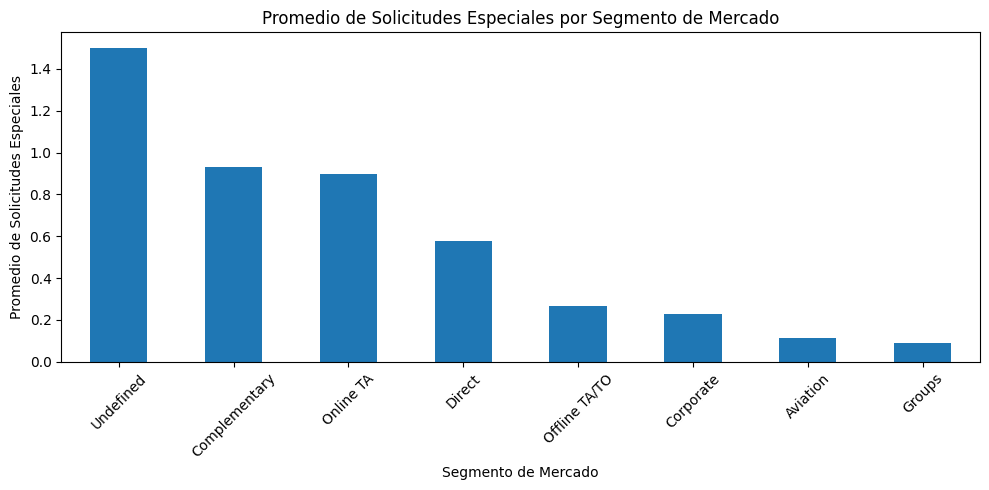

market_segment
Undefined        1.50
Complementary    0.93
Online TA        0.90
Direct           0.58
Offline TA/TO    0.27
Corporate        0.23
Aviation         0.11
Groups           0.09
Name: total_of_special_requests, dtype: float64


In [4]:
solicitudes_segmento = (
    data.groupby("market_segment")["total_of_special_requests"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
solicitudes_segmento.plot(kind="bar")

plt.title("Promedio de Solicitudes Especiales por Segmento de Mercado")
plt.xlabel("Segmento de Mercado")
plt.ylabel("Promedio de Solicitudes Especiales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(solicitudes_segmento.round(2))

El análisis muestra que los segmentos **Undefined (1,50)**, **Complementary (0,93)** y **Online TA (0,90)** presentan el mayor promedio de solicitudes especiales, indicando una mayor demanda de servicios personalizados. En contraste, los segmentos **Groups (0,09)**, **Aviation (0,11)** y **Corporate (0,23)** registran los valores más bajos, lo que sugiere reservas con menos requerimientos adicionales.

Estos resultados permiten identificar qué segmentos de clientes requieren una atención más personalizada y ayudan al hotel a planificar mejor sus recursos y servicios.


### **Insight 2: Distribución de Adultos según el Tipo de Cliente**

**Cualitativa:** `customer_type`
**Cuantitativa:** `adults`

**Objetivo:** Comprender la composición de los grupos de clientes según su tipo, apoyando la planificación operativa y asignación de recursos del hotel. Este análisis nos permite identificar patrones en el tamaño de los grupos que reservan, lo cual es fundamental para la gestión de habitaciones, la preparación de servicios y la personalización de la experiencia del huésped.




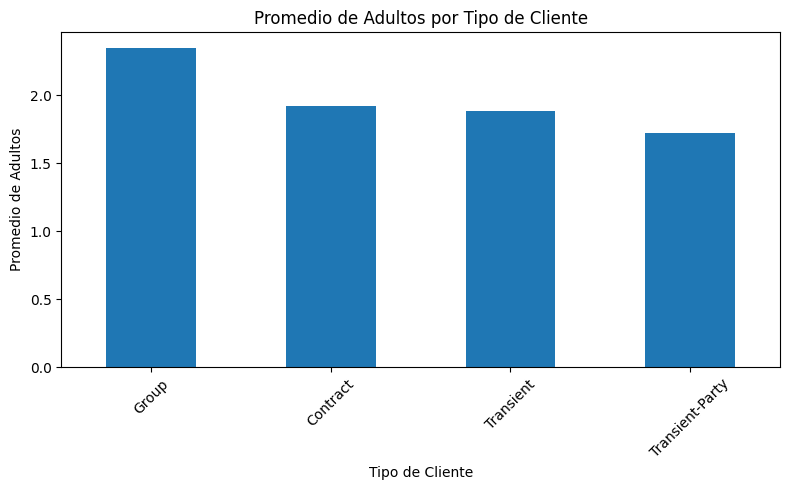

customer_type
Group              2.35
Contract           1.92
Transient          1.89
Transient-Party    1.73
Name: adults, dtype: float64


In [7]:
adultos_tipo = (
    data.groupby("customer_type")["adults"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

adultos_tipo.plot(kind='bar')

plt.title('Promedio de Adultos por Tipo de Cliente')
plt.xlabel('Tipo de Cliente')
plt.ylabel('Promedio de Adultos')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(adultos_tipo.round(2))

El análisis muestra que los clientes de tipo **Group** presentan el mayor promedio de adultos por reserva (2,35), seguidos por **Contract** (1,92) y **Transient** (1,89). Por otro lado, los clientes **Transient-Party** registran el promedio más bajo (1,73).

Estos resultados indican que las reservas grupales suelen estar compuestas por un mayor número de adultos, mientras que otros tipos de clientes realizan reservas para grupos más pequeños. Esta información puede ayudar al hotel a planificar la asignación de habitaciones y recursos según las características de cada tipo de cliente.


#**Fase 3 | Preparación de los datos**

----

###**Tratamiento de Valores Duplicados y creacion de copia**



In [ ]:
data_tutin = data.copy()

In [ ]:
data_tutin = data.drop_duplicates()

##Transformacion de variables numericas

In [ ]:
# Ver columnas float64
print(data_tutin.select_dtypes(include='float64').columns)

# Convertir variables float64 a int64, excepto 'adr'
for col in data_tutin.select_dtypes(include='float64').columns:
    if col != 'adr':
        data_tutin[col] = data_tutin[col].fillna(0).astype('int64')

# Verificar cambios
print(data_tutin.dtypes)

Index(['children', 'agent', 'company', 'adr'], dtype='object')
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                            int64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type 

###**Tratamiento de Valores Nulos**

Primero, vamos a manejar los valores nulos en el DataFrame. Identificamos columnas con NaN y decidimos cómo tratarlos: rellenar con un valor por defecto o eliminar la columna si tiene demasiados nulos.

###Tratamiento de valores nulos en variables categoricas

In [ ]:
# Obtener la moda
moda_country = data_tutin['country'].mode()[0]

# Imputar nulos
data_tutin['country'] = data_tutin['country'].fillna(moda_country)

###Tratamiento de valores nulos en variables numericas

**Tratamiento de Valores Negativos en 'adr'**

La columna 'adr' (Tarifa Diaria Promedio) no debería tener valores negativos, ya que representan un precio. Corregiremos estos valores anómalos reemplazándolos con la mediana de 'adr', que es una medida robusta ante valores extremos.

In [ ]:
# Calcular la mediana de 'adr' para usarla como reemplazo
median_adr = data_tutin['adr'].median()

# Aplicar una función lambda para reemplazar cualquier valor negativo en 'adr' con la mediana
data_tutin['adr'] = data_tutin['adr'].apply(lambda x: median_adr if x < 0 else x)

print("Verificación de valores negativos en 'adr' (debería ser False después del tratamiento):")
display((data_tutin['adr'] < 0).any())

Verificación de valores negativos en 'adr' (debería ser False después del tratamiento):


np.False_

In [ ]:
# Reemplazar nulos por 0
data_tutin['agent'] = data_tutin['agent'].fillna(0)
data_tutin['company'] = data_tutin['company'].fillna(0)

In [ ]:
# Calcular la media
media_children = data_tutin['children'].mean()

# Imputar nulos con la media
data_tutin['children'] = data_tutin['children'].fillna(media_children)

In [ ]:
print("Valores nulos después del tratamiento:")

display(
    data_tutin.isnull()
              .sum()
              .rename("Cantidad de nulos por columna")
)

Valores nulos después del tratamiento:


,Cantidad de nulos por columna
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


### **Tratamiento de Valores Atípicos (Outliers)**

Para manejar los valores atípicos, utilizaremos la técnica de 'capping' (delimitación) basada en el Rango Intercuartílico (IQR). Esto significa que cualquier valor que se encuentre por debajo del límite inferior o por encima del límite superior del IQR será reemplazado por dicho límite. Esto ayuda a reducir la influencia de los valores extremos sin eliminar completamente los datos.

In [ ]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    df[column] = df[column].apply(lambda x: limite_inferior if x < limite_inferior else (limite_superior if x > limite_superior else x))
    return df

# Columnas identificadas con outliers relevantes y que se mantienen en el DataFrame
columns_with_outliers_to_treat = [
     'lead_time',
     'total_of_special_requests',
     'required_car_parking_spaces',
     'adr',
     'babies',
     'stays_in_week_nights',
     'stays_in_weekend_nights',
     'adults',
     'booking_changes',
     'previous_cancellations',
     'children',
     'is_repeated_guest',
     'days_in_waiting_list',
]

for col in columns_with_outliers_to_treat:
    data_tutin = cap_outliers_iqr(data, col)
    print(f"Outliers tratados en la columna '{col}'.")

print("\nValores atípicos después del tratamiento (se espera que sean 0 para las columnas tratadas o muy reducidos):")

outliers_iqr_after_treatment = contar_outliers_iqr(data_tutin)
display(outliers_iqr_after_treatment[outliers_iqr_after_treatment['columna'].isin(columns_with_outliers_to_treat)])

Outliers tratados en la columna 'lead_time'.
Outliers tratados en la columna 'total_of_special_requests'.
Outliers tratados en la columna 'required_car_parking_spaces'.
Outliers tratados en la columna 'adr'.
Outliers tratados en la columna 'babies'.
Outliers tratados en la columna 'stays_in_week_nights'.
Outliers tratados en la columna 'stays_in_weekend_nights'.
Outliers tratados en la columna 'adults'.
Outliers tratados en la columna 'booking_changes'.
Outliers tratados en la columna 'previous_cancellations'.
Outliers tratados en la columna 'children'.
Outliers tratados en la columna 'is_repeated_guest'.
Outliers tratados en la columna 'days_in_waiting_list'.

Valores atípicos después del tratamiento (se espera que sean 0 para las columnas tratadas o muy reducidos):


,columna,outliers,porcentaje_outliers,limite_inferior,limite_superior
3,lead_time,0,0.0,-195.00,373.00
6,stays_in_week_nights,0,0.0,-2.00,6.00
7,stays_in_weekend_nights,0,0.0,-3.00,5.00
8,children,0,0.0,0.00,0.00
9,babies,0,0.0,0.00,0.00
10,is_repeated_guest,0,0.0,0.00,0.00
11,adults,0,0.0,2.00,2.00
12,previous_cancellations,0,0.0,0.00,0.00
13,booking_changes,0,0.0,0.00,0.00
16,days_in_waiting_list,0,0.0,0.00,0.00


### **Crear columnas nuevas**

In [ ]:
data_tutin["total_stays"] = data_tutin["stays_in_week_nights"] + data_tutin["stays_in_weekend_nights"]

Creamos una columna que guarda el total de noches que queda la persona

In [ ]:
data_tutin["lead_time_cat"] = pd.cut(
    data_tutin["lead_time"],
    bins=[-1, 0, 30, 180, 1000],
    labels=[
        "Mismo día",
        "Corto plazo (≤1 mes)",
        "Medio plazo (1-6 meses)",
        "Largo plazo (>6 meses)"
    ]
)

Se creó una variable categórica a partir de lead_time con el fin de facilitar la interpretación del tiempo de anticipación de las reservas, clasificándolas en reservas de mismo día, corto, medio y largo plazo.

In [ ]:
data_tutin.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_stays,lead_time_cat
0,Resort Hotel,0,342.0,2015,July,27,1,0.0,0.0,2.0,...,NaN,0.0,Transient,0.0,0.0,0.0,Check-Out,2015-07-01,0.0,Largo plazo (>6 meses)
1,Resort Hotel,0,373.0,2015,July,27,1,0.0,0.0,2.0,...,NaN,0.0,Transient,0.0,0.0,0.0,Check-Out,2015-07-01,0.0,Largo plazo (>6 meses)
2,Resort Hotel,0,7.0,2015,July,27,1,0.0,1.0,2.0,...,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,2015-07-02,1.0,Corto plazo (≤1 mes)
3,Resort Hotel,0,13.0,2015,July,27,1,0.0,1.0,2.0,...,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,2015-07-02,1.0,Corto plazo (≤1 mes)
4,Resort Hotel,0,14.0,2015,July,27,1,0.0,2.0,2.0,...,NaN,0.0,Transient,98.0,0.0,1.0,Check-Out,2015-07-03,2.0,Corto plazo (≤1 mes)


### **Ver correlaciones con data mas limpia**

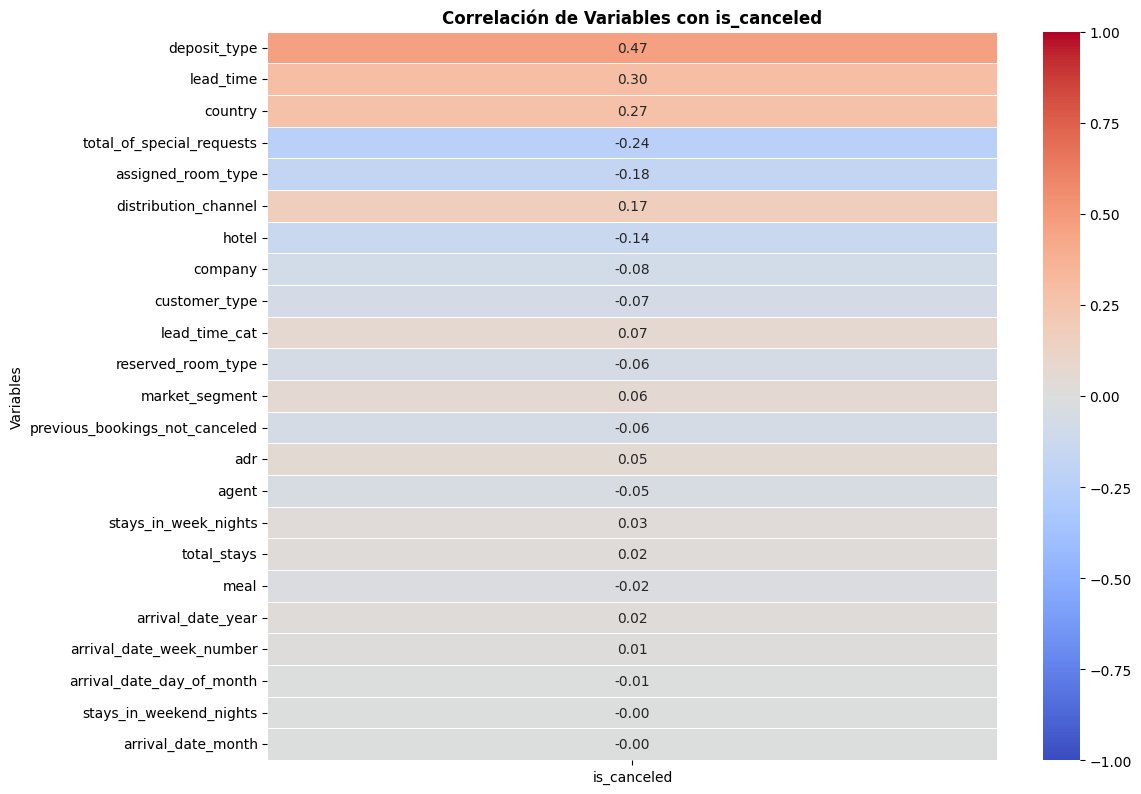

In [ ]:
from sklearn.preprocessing import LabelEncoder

data_corr = data_tutin.copy()

columnas_eliminar = [
    'reservation_status',
    'reservation_status_date'
]

data_corr = data_corr.drop(columns=columnas_eliminar)

for col in data_corr.select_dtypes(include='category').columns:
    data_corr[col] = data_corr[col].astype('object')

for col in data_corr.columns:

    if data_corr[col].dtype in ['int64', 'float64']:
        data_corr[col] = data_corr[col].fillna(0)

    else:
        data_corr[col] = data_corr[col].fillna('Desconocido')

le = LabelEncoder()

for col in data_corr.select_dtypes(include=['object', 'bool']).columns:
    data_corr[col] = le.fit_transform(data_corr[col].astype(str))

corr = data_corr.corr(numeric_only=True)

corr_target = corr[['is_canceled']].drop('is_canceled')

corr_target = corr_target.dropna()

corr_target = corr_target.reindex(
    corr_target['is_canceled']
    .abs()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, len(corr_target) * 0.35))

sns.heatmap(
    corr_target,annot=True,fmt='.2f',cmap='coolwarm',vmin=-1,vmax=1,linewidths=.5
)

plt.title(
    'Correlación de Variables con is_canceled',
    fontweight='bold'
)

plt.ylabel('Variables')

plt.tight_layout()

plt.show()

### **Eliminación de columnas no necesarias**

In [ ]:
columns_to_keep = [
    'is_canceled',
    'deposit_type',
    'lead_time',
    'country',
    'total_of_special_requests',
    'required_car_parking_spaces',
    'assigned_room_type',
    'distribution_channel',
    'hotel',
    'is_repeated_guest',
    'customer_type',
    'lead_time_cat',
    'reserved_room_type',
    'market_segment',
    'adr',
    'babies',
    'stays_in_week_nights',
    'total_stays',
    'meal',
    'arrival_date_year',
    'arrival_date_week_number',
    'arrival_date_day_of_month',
    'arrival_date_month',
    'stays_in_weekend_nights',
    'adults',
    'booking_changes',
    'previous_cancellations'
]

 # Esta parte tengo analizar si dejarla o no
# columnas_excluir = [
#     'company' 00,8,
#     'agent' 00,5,
#     'reservation_status' estas son comprometedoras tengo fuera,
#     'reservation_status_date estas son comprometedoras tengo fuera'
# ]

# Obtener las columnas a eliminar
columns_to_drop = [col for col in data_tutin.columns if col not in columns_to_keep]

# Eliminar las columnas
data_tutin = data_tutin.drop(columns=columns_to_drop)

print("Columnas después de la eliminación:")
display(data_tutin.info())

Columnas después de la eliminación:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 27 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   hotel                        119390 non-null  object  
 1   is_canceled                  119390 non-null  int64   
 2   lead_time                    119390 non-null  float64 
 3   arrival_date_year            119390 non-null  int64   
 4   arrival_date_month           119390 non-null  object  
 5   arrival_date_week_number     119390 non-null  int64   
 6   arrival_date_day_of_month    119390 non-null  int64   
 7   stays_in_weekend_nights      119390 non-null  float64 
 8   stays_in_week_nights         119390 non-null  float64 
 9   adults                       119390 non-null  float64 
 10  babies                       119390 non-null  float64 
 11  meal                         119390 non-null  object  
 12  country 

None

Se eliminan las variables las cuales no posee correlacion con la variable objetivo en especial se elimina la variable `reservarion status` y `reservation date` ya que si se entrena el modelo con estas variables, el modelo ve la respuesta sucediendo un data leakage.

#**Fase 4 | Modelado**

Como la variable objetivo **`is_canceled`** presenta una respuesta binaria (0 = reserva no cancelada, 1 = reserva cancelada), el problema corresponde a una tarea de **clasificación supervisada**. Por este motivo, se utilizarán distintos modelos de clasificación con el objetivo de determinar cuál ofrece la mejor capacidad predictiva para identificar si un cliente cancelará o no su reserva hotelera.

Los modelos seleccionados para el análisis son:

* Regresión Logística.
* K-Nearest Neighbors (KNN).
* Árbol de Decisión.
* Random Forest.
* Support Vector Machine (SVM) con kernel lineal.
* Support Vector Machine (SVM) con kernel RBF (no lineal).

Todos los modelos serán entrenados utilizando las variables predictoras seleccionadas del dataset, mientras que la variable objetivo será **is_canceled**. Posteriormente, los resultados serán comparados mediante métricas de clasificación como Accuracy, Precision, Recall y F1-score, con el fin de seleccionar el modelo que presente el mejor desempeño para la predicción de cancelaciones hoteleras.





##Definicion variable objetivo para el modelo

In [ ]:
y = data_tutin['is_canceled']
X = data_tutin.drop('is_canceled', axis=1)

##División de datos

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento : {X_train.shape[0]} registros")
print(f"Prueba        : {X_test.shape[0]} registros")

Entrenamiento : 95512 registros
Prueba        : 23878 registros


Dejamos el 80% de los valores a entrenamiento y el 20% de prueba

##Definición de variables numéricas y categóricas

In [ ]:
features_num = [
     'lead_time',
     'total_of_special_requests',
     'required_car_parking_spaces',
     'adr',
     'babies',
    # 'stays_in_week_nights',
     'stays_in_weekend_nights',
     'total_stays',
     'adults',
     'booking_changes',
     'previous_cancellations',
     'arrival_date_year',
    # 'arrival_date_week_number',
    # 'arrival_date_day_of_month'
]

features_cat = [
     'deposit_type',
     'country',
     'assigned_room_type',
     'distribution_channel',
     'hotel',
     'is_repeated_guest',
     'customer_type',
     'lead_time_cat',
     'reserved_room_type',
     'market_segment',
    # 'meal',
    # 'arrival_date_month',
]

Las variables utilizadas en el modelado fueron seleccionadas mediante un análisis exploratorio de datos, considerando aquellas que presentaban una mayor relación con la variable objetivo **is_canceled**. Se incluyeron tanto variables numéricas como categóricas que mostraron capacidad para explicar el comportamiento de las cancelaciones de reservas.

La selección tuvo como objetivo conservar las características más relevantes para la predicción y reducir la incorporación de variables con baja contribución al modelo. Entre ellas se encuentran variables asociadas al comportamiento de reserva, características del cliente, historial de cancelaciones, tipo de alojamiento, canal de distribución, segmento de mercado y condiciones de la reserva.

De esta manera, los modelos fueron entrenados utilizando aquellas variables que presentaban una mayor correlación o asociación con la cancelación de reservas, buscando mejorar la capacidad predictiva y la interpretación de los resultados obtenidos.


##Construcción del preprocesador

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
    ]
)

In [ ]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

Se le aplica **estandarización** con StandardScaler de las variable numericas y **codificacion** con OneHotEncoder categorica a las variable categoricas

##Transformación de datos y generación de dataset procesado

In [ ]:
# Pipeline SOLO para transformar
#pipe_pre = Pipeline(steps=[
#    ('preprocessor', preprocessor)
#])

# Transformar
#X_trans = pipe_pre.fit_transform(X)

# Nombres columnas
#columnas = pipe_pre.named_steps[
#    "preprocessor"
#].get_feature_names_out()

# Convertir sparse matrix a array normal
#X_trans_dense = X_trans.toarray()

# Crear DataFrame
#data_pipe = pd.DataFrame(
#    X_trans_dense,
#    columns=columnas,
#    index=X.index
#)

# Guardar CSV
#data_pipe.to_csv(
#    "data_preparada_hotel.csv",
#    index=False
#)

# Mostrar
#data_pipe.head()

Se aplica el preprocesamiento definido previamente para transformar las variables
numéricas y categóricas, generando un dataset listo para su uso en modelos de machine learning.

##Creación de modelo regresion logistica

In [ ]:
def evaluar_modelo(nombre, modelo, X_test, y_test):

    y_pred = modelo.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    vn, fp, fn, vp = cm.ravel()

    fig, ax = plt.subplots(figsize=(6, 5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Cancelado", "Cancelado"]
    )

    disp.plot(cmap="Blues", ax=ax, values_format='d')

    plt.title(f"Matriz de Confusión - {nombre}")

    # Etiquetas en español dentro del gráfico

    ax.text(0, -0.18, "VN", ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(1, -0.18, "FP", ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(0, 0.82, "FN", ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(1, 0.82, "VP", ha='center', va='center', fontsize=12, fontweight='bold')
    plt.show()

    print("\n--- Reporte de Clasificación ---")
    print(classification_report(y_test, y_pred))

    print("\n--- Métricas principales ---")
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"F1-score  : {f1_score(y_test, y_pred):.4f}")

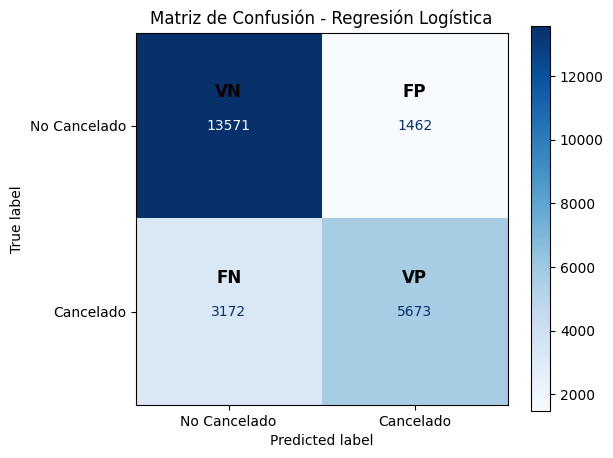


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.81      0.90      0.85     15033
           1       0.80      0.64      0.71      8845

    accuracy                           0.81     23878
   macro avg       0.80      0.77      0.78     23878
weighted avg       0.80      0.81      0.80     23878


--- Métricas principales ---
Accuracy  : 0.8059
Precision : 0.7951
Recall    : 0.6414
F1-score  : 0.7100


In [ ]:
modelo_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

modelo_lr.fit(X_train, y_train)

evaluar_modelo(
    "Regresión Logística",
    modelo_lr,
    X_test,
    y_test
)

1. **Accuracy**: La exactitud mide qué tan correctas son las predicciones del modelo en general.

2. **Precision**: La precisión indica cuántas de las predicciones positivas fueron realmente correctas

3. **Recall**: mide qué proporción de los casos positivos reales fueron correctamente identificados, enfocándose en capturar todos los positivos.

4. **F1-Score**: El F1-Score combina precisión y el recall en un único valor, siendo útil cuando ambos son importantes, especialmente en datasets desbalanceados.


##Guardar el resultado del modelo con variacion de variables

In [ ]:
# Lista para guardar resultados NO EJECUTAR DE NUEVO ESTA COLUMNA PORQUE ME BORRAN LA LISTA
resultados_modelos = []

In [ ]:
# # =========================
# # NOMBRE DEL EXPERIMENTO
# # =========================
nombre_modelo = "Prueba 2"

# Predicciones
y_pred_lr = modelo_lr.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_lr)

vn, fp, fn, vp = cm.ravel()

# Métricas
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

# Guardar resultado
resultados_modelos.append({
    'Modelo': nombre_modelo,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1,
    'VN': vn,
    'FP': fp,
    'FN': fn,
    'VP': vp
})

# Convertir a DataFrame
df_resultados = pd.DataFrame(resultados_modelos)

# Ordenar por Accuracy de mayor a menor
df_resultados = df_resultados.sort_values(
    by='Accuracy',
    ascending=False
)

# Mostrar resultados
display(df_resultados)

,Modelo,Accuracy,Precision,Recall,F1-score,VN,FP,FN,VP
0,Prueba 2,0.80593,0.795095,0.641379,0.710013,13571,1462,3172,5673


In [ ]:
# Guardar resultados en CSV
# df_resultados.to_csv(
#     'resultados_modelos.csv',
#     index=False
# )

# df_resultados = pd.read_csv('resultados_modelos.csv')

# # Convertir nuevamente a lista de diccionarios
# resultados_modelos = df_resultados.to_dict('records')

##Mostrar pruebas hechas antes

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/NicolasLizama/Titanicsehundio/main/resultados_modelos.csv"

df_resultados = pd.read_csv(url)

# Mostrarlo ordenado por Accuracy
df_resultados = df_resultados.sort_values(by="Accuracy", ascending=False)

display(df_resultados)

,Modelo,Accuracy,Precision,Recall,F1-score,VN,FP,FN,VP
0,testing con TODO,0.830346,0.803418,0.717581,0.758077,13480,1553,2498,6347
1,Elegida con distribution_channel,0.830346,0.803418,0.717581,0.758077,13480,1553,2498,6347
2,testing con distribution_channel,0.803334,0.800174,0.625212,0.701955,13652,1381,3315,5530
3,testing con assigned_room_type,0.798476,0.795978,0.613115,0.692681,13643,1390,3422,5423
4,testing con customer_type,0.791984,0.787344,0.600678,0.681460,13598,1435,3532,5313
5,testing con booking_changes y special,0.787252,0.789660,0.580215,0.668926,13666,1367,3713,5132
6,testing con required_car_parking_spaces con co...,0.777955,0.773506,0.566422,0.653962,13566,1467,3835,5010
7,testing con required_car_parking_spaces sin co...,0.775191,0.776347,0.552176,0.645349,13626,1407,3961,4884
8,testing con company,0.768699,0.773371,0.531261,0.629851,13656,1377,4146,4699
9,testing con is_repeated_guest,0.768029,0.771161,0.531487,0.629275,13638,1395,4144,4701


##Modelo KNN

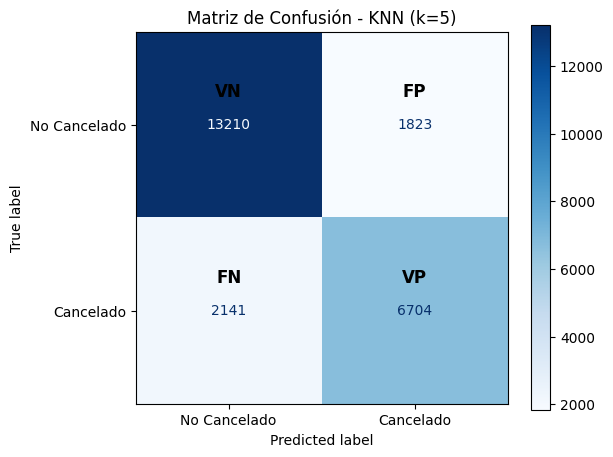


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.86      0.88      0.87     15033
           1       0.79      0.76      0.77      8845

    accuracy                           0.83     23878
   macro avg       0.82      0.82      0.82     23878
weighted avg       0.83      0.83      0.83     23878


--- Métricas principales ---
Accuracy  : 0.8340
Precision : 0.7862
Recall    : 0.7579
F1-score  : 0.7718


In [ ]:
modelo_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

modelo_knn.fit(X_train, y_train)

evaluar_modelo(
    "KNN (k=5)",
    modelo_knn,
    X_test,
    y_test
)

##Modelo arbol de decision

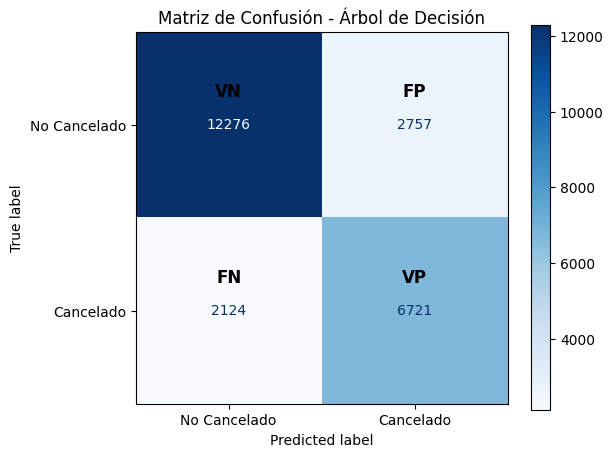


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.85      0.82      0.83     15033
           1       0.71      0.76      0.73      8845

    accuracy                           0.80     23878
   macro avg       0.78      0.79      0.78     23878
weighted avg       0.80      0.80      0.80     23878


--- Métricas principales ---
Accuracy  : 0.7956
Precision : 0.7091
Recall    : 0.7599
F1-score  : 0.7336


In [ ]:
modelo_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=5, random_state=42))
])

modelo_tree.fit(X_train, y_train)

evaluar_modelo(
    "Árbol de Decisión",
    modelo_tree,
    X_test,
    y_test
)

##Modelo Random Forest

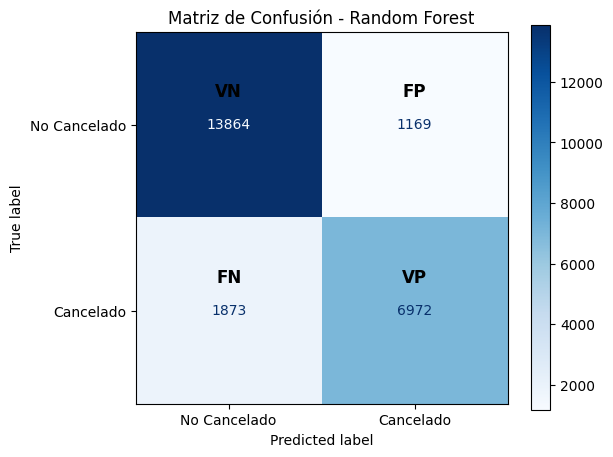


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.88      0.92      0.90     15033
           1       0.86      0.79      0.82      8845

    accuracy                           0.87     23878
   macro avg       0.87      0.86      0.86     23878
weighted avg       0.87      0.87      0.87     23878


--- Métricas principales ---
Accuracy  : 0.8726
Precision : 0.8564
Recall    : 0.7882
F1-score  : 0.8209


In [ ]:
modelo_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

modelo_rf.fit(X_train, y_train)

evaluar_modelo(
    "Random Forest",
    modelo_rf,
    X_test,
    y_test
)

##Modelo SVM (con kernel rbf)

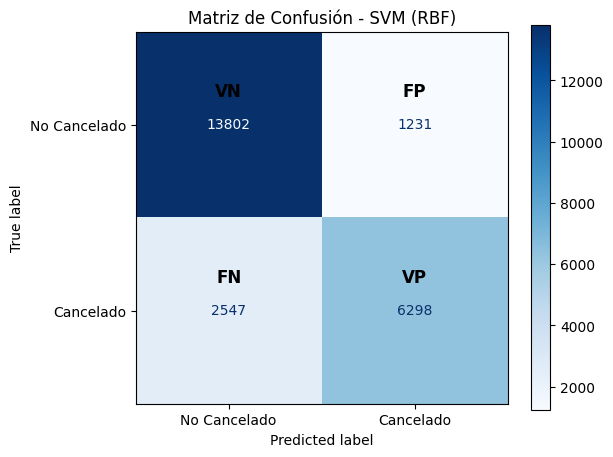


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.84      0.92      0.88     15033
           1       0.84      0.71      0.77      8845

    accuracy                           0.84     23878
   macro avg       0.84      0.82      0.82     23878
weighted avg       0.84      0.84      0.84     23878


--- Métricas principales ---
Accuracy  : 0.8418
Precision : 0.8365
Recall    : 0.7120
F1-score  : 0.7693


In [ ]:
modelo_svm = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(
        kernel='rbf',
        random_state=42
    ))
])

modelo_svm.fit(X_train, y_train)

evaluar_modelo(
    "SVM (RBF)",
    modelo_svm,
    X_test,
    y_test
)

##Modelo SVM con kernel lineal

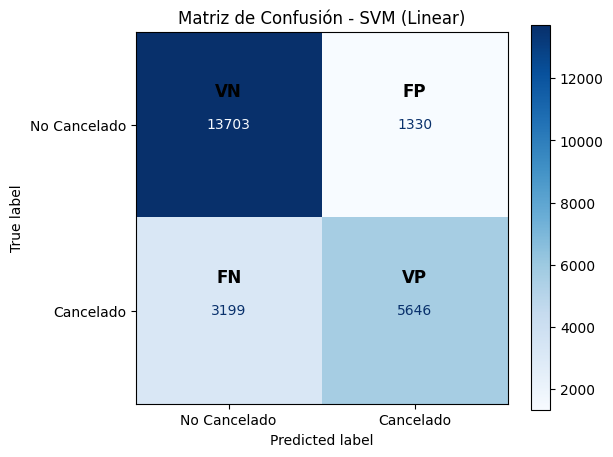


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.81      0.91      0.86     15033
           1       0.81      0.64      0.71      8845

    accuracy                           0.81     23878
   macro avg       0.81      0.77      0.79     23878
weighted avg       0.81      0.81      0.80     23878


--- Métricas principales ---
Accuracy  : 0.8103
Precision : 0.8093
Recall    : 0.6383
F1-score  : 0.7137


In [ ]:
modelo_svm_linear = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(
        kernel='linear',
        random_state=42
    ))
])

modelo_svm_linear.fit(X_train, y_train)

evaluar_modelo(
    "SVM (Linear)",
    modelo_svm_linear,
    X_test,
    y_test
)

#**Fase 5 | Evaluación**

##Guadar resultados de los modelos

In [ ]:
resultados_modelos = []

In [ ]:
def guardar_metricas(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    resultados_modelos.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0)
    })

In [ ]:
guardar_metricas("Árbol de Decisión", modelo_tree, X_test, y_test)
guardar_metricas("KNN (k=5)", modelo_knn, X_test, y_test)
guardar_metricas("Regresión Logística", modelo_lr, X_test, y_test)
guardar_metricas("SVM (RBF)", modelo_svm, X_test, y_test)
guardar_metricas("SVM (Linear)", modelo_svm_linear, X_test, y_test)
guardar_metricas("Random Forest", modelo_rf, X_test, y_test)

##Comparar resultados de los modelos de clasificación

In [ ]:
df_resultados = pd.DataFrame(resultados_modelos)

df_ordenado = df_resultados.sort_values(by="Precision", ascending=False)

display(df_ordenado)

,Modelo,Accuracy,Precision,Recall,F1-score
5,Random Forest,0.872602,0.856406,0.788242,0.820911
3,SVM (RBF),0.841779,0.836499,0.712041,0.769268
4,SVM (Linear),0.810327,0.809346,0.638327,0.713735
2,Regresión Logística,0.805930,0.795095,0.641379,0.710013
1,KNN (k=5),0.833989,0.786209,0.757942,0.771817
0,Árbol de Decisión,0.795586,0.709116,0.759864,0.733613


El mejor modelo de clasificación es Random Forest, ya que presenta buenos valores de accuracy, precision, recall y F1-score. Este será el modelo con el cual realizaremos el despliegue.

##Ver las features mas importantes para el modelo seleccionado

In [ ]:
rf = modelo_rf.named_steps['model']

feature_names = modelo_rf.named_steps['preprocessor'].get_feature_names_out()

importancias = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(importancias.head(20))

num__lead_time                                0.158428
num__adr                                      0.142891
cat__country_PRT                              0.071092
num__total_of_special_requests                0.064610
num__total_stays                              0.063559
cat__deposit_type_Non Refund                  0.059208
cat__deposit_type_No Deposit                  0.057114
num__arrival_date_year                        0.034292
num__stays_in_weekend_nights                  0.034129
cat__market_segment_Online TA                 0.021196
cat__customer_type_Transient                  0.018063
cat__assigned_room_type_A                     0.015308
cat__customer_type_Transient-Party            0.015223
cat__lead_time_cat_Largo plazo (>6 meses)     0.014519
cat__market_segment_Groups                    0.014405
cat__market_segment_Offline TA/TO             0.014297
cat__lead_time_cat_Corto plazo (≤1 mes)       0.014108
cat__country_GBR                              0.009405
cat__distr

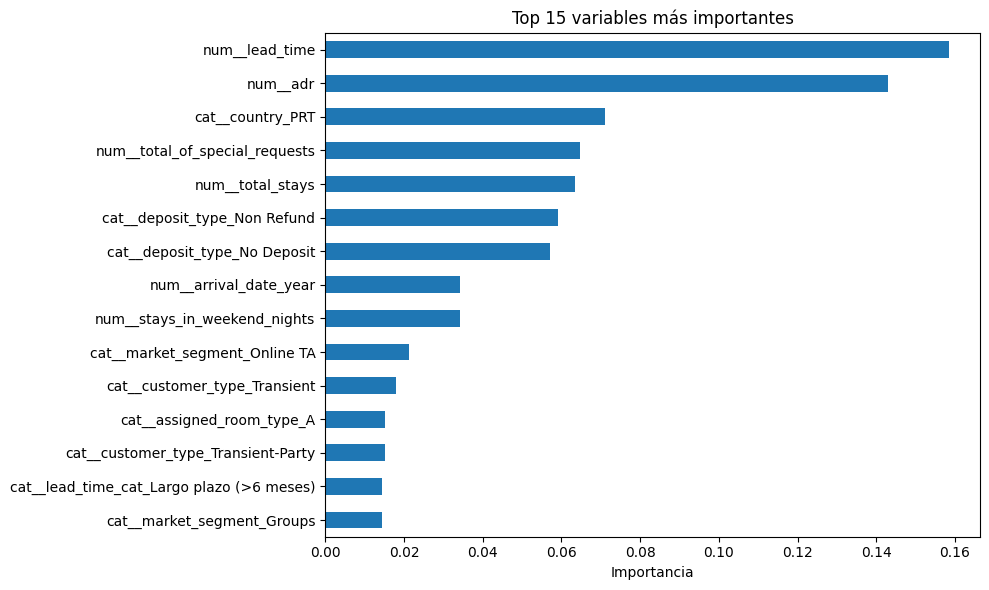

In [ ]:
plt.figure(figsize=(10,6))

importancias.head(15).sort_values().plot(kind='barh')

plt.title("Top 15 variables más importantes")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

`Lead time`
`ADR` `Country` Tienen demasiada importancia para el modelo de Random Forest

Las demas la importancia que tienen son mas moderadas

Esto quiere decir que:

  `Lead time`: Representa la reserva los dias entre la reserva y la llegada al hotel que va el cliente, se puede inferir que **entre mas anticipada sea la reserva es mas probable que el cliente cancele su estadia en el hotel**



`adr`: Corresponde a la tarifa diaria promedio de la reserva. Las reservas con precios más altos o más bajos presentan patrones distintos de cancelación.
**El precio influye significativamente en la decisión final del cliente.**



